In [1]:
import networkx as nx
import numpy as np
import os
import sys
sys. path.append("./functions")  # 将自定义模块路径添加到系统路径
import math_calculation as ac
import tree_viz  # 现在可以直接导入模块
import graph_operation as gop
import matplotlib.pyplot as plt

tree_vec_all = []
tree_vec_all2 = []
tree_vec_marker = []
tree_node_num = []
name_list = []
name_list2 = []

folder = "./data"

def collectData(folder_path, data_marker, name_prefix, tree_vec_all, tree_vec_all2, tree_vec_marker, tree_node_num, name_list):
    all_files = [f for f in os.listdir(folder_path) if f.endswith(('.h5', '.hdf5'))]

    for idx, f in enumerate(all_files):
        file_path = os.path.join(folder_path, f) 
        print(file_path)
        graph = gop.get_graph(file_path)
        graph = gop.merge_degree_one_nodes(graph)
        graph = gop.split_degree_three_nodes(graph)
        graph = ac.calc_edge_type_l2(graph)
        tree_vec = ac.get_tree_kernel_composition_vec(graph)
        tree_vec2 = ac.get_tree_kernel_composition_vec(graph, False)
        tree_vec_all.append(tree_vec)
        tree_vec_all2.append(tree_vec2)

        tree_vec_marker.append(data_marker)
        tree_node_num.append(len(graph))
        name_list.append(name_prefix+str(idx))
        name_list2.append(f)

def collectData2(graph, data_marker, name_prefix, tree_vec_all, tree_vec_all2, tree_vec_marker, tree_node_num, name_list):

    graph = ac.calc_edge_type_l2(graph)
    tree_vec = ac.get_tree_kernel_composition_vec(graph)
    tree_vec2 = ac.get_tree_kernel_composition_vec(graph, False)
    tree_vec_all.append(tree_vec)
    tree_vec_all2.append(tree_vec2)

    tree_vec_marker.append(data_marker)
    tree_node_num.append(len(graph))
    name_list.append(name_prefix+str(idx))

D:\ProgramData\miniconda3\envs\graph\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
folder_path = os.path.join(folder, 'MouseAirway')
data_marker = -1
name_prefix = "mAirway"
# collectData(folder_path, data_marker, name_prefix, tree_vec_all, tree_vec_all2, tree_vec_marker, tree_node_num, name_list)
all_files = [f for f in os.listdir(folder_path) 
            if f.endswith(('.h5', '.hdf5'))]
cr_list = [6, 6, 6, 6, 4, 6, 6, 6, 6, 6]
mi_list = [14, 15, 14, 14, 20, 14, 14, 14, 30, 14]
cudal_list = [31, 28, 31, 31, 21, 31, 31, 31, 31, 31]
ac_list =    [30, 29, 30, 30, 23, 30, 30, 30, 28, 30]
for idx, f in enumerate(all_files):
    file_path = os.path.join(folder_path, f) 
    print(file_path)
    graph = gop.get_graph(file_path)
    graph = gop.merge_degree_one_nodes(graph)
    graph = gop.split_degree_three_nodes(graph)
    graph_cr = gop.extract_subtree_bfs(graph, root=cr_list[idx], max_depth=30000, include_parent = True)
    graph_mi = gop.extract_subtree_bfs(graph, root=mi_list[idx], max_depth=30000, include_parent = True)
    graph_cudal = gop.extract_subtree_bfs(graph, root=cudal_list[idx], max_depth=30000, include_parent = True)
    graph_ac = gop.extract_subtree_bfs(graph, root=ac_list[idx], max_depth=30000, include_parent = True)
    graph_1200 = gop.prune_tree(graph, 1200)
    graph_800 = gop.prune_tree(graph, 800)
    graph_500 = gop.prune_tree(graph, 500)
    graph_200 = gop.prune_tree(graph, 200)
    graph_50 = gop.prune_tree(graph, 50)
    # collectData2(graph, data_marker, name_prefix, tree_vec_all, tree_vec_all2, tree_vec_marker, tree_node_num, name_list)
    collectData2(graph_1200, data_marker+1, name_prefix+'_Pru1_', tree_vec_all, tree_vec_all2, tree_vec_marker, tree_node_num, name_list)
    name_list2.append(f)
    collectData2(graph_800, data_marker+2, name_prefix+'_Pru2_', tree_vec_all, tree_vec_all2, tree_vec_marker, tree_node_num, name_list)
    name_list2.append(f)
    collectData2(graph_500, data_marker+3, name_prefix+'_Pru3_', tree_vec_all, tree_vec_all2, tree_vec_marker, tree_node_num, name_list)
    name_list2.append(f)
    collectData2(graph_200, data_marker+4, name_prefix+'_Pru4_', tree_vec_all, tree_vec_all2, tree_vec_marker, tree_node_num, name_list)
    name_list2.append(f)
    collectData2(graph_50, data_marker+5, name_prefix+'_Pru5_', tree_vec_all, tree_vec_all2, tree_vec_marker, tree_node_num, name_list)
    name_list2.append(f)
    collectData2(graph_cr, data_marker+6, name_prefix+'_Cr_', tree_vec_all, tree_vec_all2, tree_vec_marker, tree_node_num, name_list)
    name_list2.append(f+'_Cr')
    collectData2(graph_mi, data_marker+7, name_prefix+'_Mi_', tree_vec_all, tree_vec_all2, tree_vec_marker, tree_node_num, name_list)
    name_list2.append(f+'_Mi')
    collectData2(graph_cudal, data_marker+8, name_prefix+'_Cudal_', tree_vec_all, tree_vec_all2, tree_vec_marker, tree_node_num, name_list)
    name_list2.append(f+'_Cudal')
    collectData2(graph_ac, data_marker+9, name_prefix+'_Ac_', tree_vec_all, tree_vec_all2, tree_vec_marker, tree_node_num, name_list)
    name_list2.append(f+'_Ac')


./data\MouseAirway\m01_AirwayTree.h5
There are some nodes have out-degree more than 3.
1850
split out degree 3 node: 1079
1851
split out degree 3 node: 933
1852
split out degree 3 node: 1295
1853
split out degree 3 node: 683
./data\MouseAirway\m02_AirwayTree.h5
There are some nodes have out-degree more than 3.
1557
split out degree 3 node: 1058
1558
split out degree 3 node: 163
1559
split out degree 3 node: 30
./data\MouseAirway\m07_AirwayTree.h5
There are some nodes have out-degree more than 3.
1565
split out degree 3 node: 72
1566
split out degree 3 node: 163
1567
split out degree 3 node: 417
./data\MouseAirway\m08_AirwayTree.h5
There are some nodes have out-degree more than 3.
1719
split out degree 3 node: 1146
1720
split out degree 3 node: 158
1721
split out degree 3 node: 175
./data\MouseAirway\m09_AirwayTree.h5
There are some nodes have out-degree more than 3.
1247
split out degree 3 node: 1146
1248
split out degree 3 node: 1186
1249
split out degree 3 node: 1210
1250
split out d

In [3]:
folder_path = os.path.join(folder, 'HumanAirway')
data_marker = 9
name_prefix = "hAirway"
all_files = [f for f in os.listdir(folder_path) 
            if f.endswith(('.h5', '.hdf5'))]

for idx, f in enumerate(all_files):
    file_path = os.path.join(folder_path, f) 
    print(file_path)
    graph = gop.get_graph(file_path)
    graph = gop.merge_degree_one_nodes(graph)
    graph = gop.split_degree_three_nodes(graph)
    graph_150 = gop.prune_tree(graph, 150)
    graph_100 = gop.prune_tree(graph, 100)
    graph_50 = gop.prune_tree(graph, 50)
    collectData2(graph_150, data_marker, name_prefix+'_Pru1_', tree_vec_all, tree_vec_all2, tree_vec_marker, tree_node_num, name_list)
    name_list2.append(f)
    collectData2(graph_100, data_marker+1, name_prefix+'_Pru2_', tree_vec_all, tree_vec_all2, tree_vec_marker, tree_node_num, name_list)
    name_list2.append(f)
    collectData2(graph_50, data_marker+2, name_prefix+'_Pru3_', tree_vec_all, tree_vec_all2, tree_vec_marker, tree_node_num, name_list)
    name_list2.append(f)

./data\HumanAirway\pulse_00003_graph.h5
./data\HumanAirway\pulse_00007_graph.h5
There are some nodes have out-degree more than 3.
171
split out degree 3 node: 10
./data\HumanAirway\pulse_00012_graph.h5
./data\HumanAirway\pulse_00014_graph.h5
There are some nodes have out-degree more than 3.
219
split out degree 3 node: 12
./data\HumanAirway\pulse_00016_graph.h5
There are some nodes have out-degree more than 3.
195
split out degree 3 node: 7
./data\HumanAirway\pulse_00017_graph.h5
There are some nodes have out-degree more than 3.
264
split out degree 3 node: 19
./data\HumanAirway\pulse_00018_graph.h5
./data\HumanAirway\pulse_00019_graph.h5
There are some nodes have out-degree more than 3.
305
split out degree 3 node: 14
./data\HumanAirway\pulse_00024_graph.h5
./data\HumanAirway\pulse_00026_graph.h5
./data\HumanAirway\pulse_00027_graph.h5
There are some nodes have out-degree more than 3.
338
split out degree 3 node: 10
339
split out degree 3 node: 87


In [4]:
folder_path = os.path.join(folder, 'LungOrganoid')
data_marker = 12
name_prefix = "LungOrgnoid"
collectData(folder_path, data_marker, name_prefix, tree_vec_all, tree_vec_all2, tree_vec_marker, tree_node_num, name_list)

folder_path = os.path.join(folder, 'MouseSalivaryGland')
data_marker = data_marker+1
name_prefix = "mSalivaryGland"
collectData(folder_path, data_marker, name_prefix, tree_vec_all, tree_vec_all2, tree_vec_marker, tree_node_num, name_list)

./data\LungOrganoid\D5-10L-skeleton.h5
./data\LungOrganoid\D5-3R-skeleton.h5
There are some nodes have out-degree more than 3.
37
split out degree 3 node: 21
./data\LungOrganoid\D5-4R-skeleton.h5
There are some nodes have out-degree more than 3.
39
split out degree 3 node: 1
removed edge10 (5, 11)
40
split out degree 3 node: 5
41
split out degree 3 node: 6
42
split out degree 3 node: 23
./data\LungOrganoid\D5-5R-skeleton.h5
There are some nodes have out-degree more than 3.
25
split out degree 3 node: 3
./data\LungOrganoid\D5-6R-skeleton.h5
./data\LungOrganoid\D5-8R-skeleton.h5
./data\LungOrganoid\D5-9L-skeleton.h5
./data\MouseSalivaryGland\E14.5_Sample1.h5
./data\MouseSalivaryGland\E14.5_Sample3.h5
./data\MouseSalivaryGland\E16.5_Sample1.h5
./data\MouseSalivaryGland\E16.5_Sample2.h5
./data\MouseSalivaryGland\E16.5_Sample3.h5
./data\MouseSalivaryGland\E18.6_Sample3.h5


In [6]:
# # save results for avoiding re-calculating again

# from scipy import io
# os.makedirs("./exported/", exist_ok=True)
# io.savemat('./exported/output.mat', {'tree_vec_data': tree_vec_all, 'tree_vec_data2': np.array(tree_vec_all2),
#                           'tree_vec_marker': np.array(tree_vec_marker), 'tree_node_num': np.array(tree_node_num), 'name_list': np.array(name_list), 'name_list2': np.array(name_list2)})

# np.save("./exported/tree_vec_all.npy",  np.array(tree_vec_all))
# np.save("./exported/tree_vec_all2.npy", np.array(tree_vec_all2))
# np.save("./exported/tree_vec_marker.npy", np.array(tree_vec_marker))
# np.save("./exported/tree_node_num.npy", np.array(tree_node_num))
# np.save("./exported/name_list.npy", np.array(name_list))
# np.save("./exported/name_list2.npy", np.array(name_list2))

In [7]:
## if results have been saved before

# import numpy as np
# tree_vec_all = np.load("./exported/tree_vec_all.npy")
# tree_vec_all2 = np.load("./exported/tree_vec_all2.npy")
# tree_vec_marker = np.load("./exported/tree_vec_marker.npy")
# tree_node_num = np.load("./exported/tree_node_num.npy")
# name_list = np.load("./exported/name_list.npy")
# name_list2 = np.load("./exported/name_list2.npy")

In [5]:
import pandas as pd
vecName = ['B', 'C', 'BB2', 'BB3', 'B-B2', 'B-B3', 'BC2', 'BC3', 'B-C2', 'B-C3', 'CB2', 'CB3', 'CC2', 'CC3']
# df = pd.DataFrame(np.array(tree_vec_all2), columns=[f'vec_{i+1}' for i in range(14)])
df = pd.DataFrame(np.array(tree_vec_all2), columns=vecName)
df['name'] = np.array(name_list2).squeeze() 
df['node_num'] = np.array(tree_node_num).squeeze()
df['marker'] = np.array(tree_vec_marker).squeeze()

df = df[['name', 'marker','node_num'] + vecName]
df.head(50)

,name,marker,node_num,B,C,BB2,BB3,B-B2,B-B3,BC2,BC3,B-C2,B-C3,CB2,CB3,CC2,CC3
0,m01_AirwayTree.h5,0,1200,439,160,75,158,41,68,25,44,21,40,21,76,12,17
1,m01_AirwayTree.h5,1,800,306,93,64,105,29,51,9,30,12,22,17,40,5,14
2,m01_AirwayTree.h5,2,500,192,57,44,65,16,28,8,19,6,19,10,29,1,3
3,m01_AirwayTree.h5,3,200,83,16,25,27,8,11,5,7,1,0,2,10,0,2
4,m01_AirwayTree.h5,4,50,21,3,7,3,3,5,0,1,1,0,3,0,0,0
5,m01_AirwayTree.h5_Cr,5,306,109,43,14,40,14,10,5,10,7,15,8,22,2,4
6,m01_AirwayTree.h5_Mi,6,234,86,30,18,32,5,17,7,5,6,7,4,9,1,4
7,m01_AirwayTree.h5_Cudal,7,508,150,103,25,41,11,20,10,22,11,33,14,38,12,15
8,m01_AirwayTree.h5_Ac,8,172,67,18,18,29,5,12,2,3,4,8,0,2,0,1
9,m02_AirwayTree.h5,0,1200,421,178,82,127,41,79,33,40,23,39,20,71,12,31


In [6]:
df[df['marker'] == 1]

,name,marker,node_num,B,C,BB2,BB3,B-B2,B-B3,BC2,BC3,B-C2,B-C3,CB2,CB3,CC2,CC3
1,m01_AirwayTree.h5,1,800,306,93,64,105,29,51,9,30,12,22,17,40,5,14
10,m02_AirwayTree.h5,1,800,302,97,62,103,27,53,21,25,13,27,8,48,3,8
19,m07_AirwayTree.h5,1,800,297,102,67,98,34,42,14,25,19,24,14,42,5,14
28,m08_AirwayTree.h5,1,800,292,107,59,100,30,44,20,29,11,19,16,43,13,14
37,m09_AirwayTree.h5,1,800,308,91,55,113,30,50,19,22,13,18,16,43,8,11
46,m10_AirwayTree.h5,1,800,296,103,53,104,27,36,20,22,11,27,19,57,4,18
55,m11_AirwayTree.h5,1,800,299,100,59,105,30,51,20,21,11,22,16,38,7,18
64,m13_AirwayTree.h5,1,800,306,93,60,102,26,53,18,21,14,27,19,46,4,8
73,m14_AirwayTree.h5,1,800,294,105,57,84,33,59,23,27,11,23,22,39,6,14
82,m16_AirwayTree.h5,1,800,286,113,55,83,37,46,20,27,3,25,25,40,16,21


D:\ProgramData\miniconda3\envs\graph\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning:

'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.

D:\ProgramData\miniconda3\envs\graph\Lib\site-packages\umap\umap_.py:1952: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.



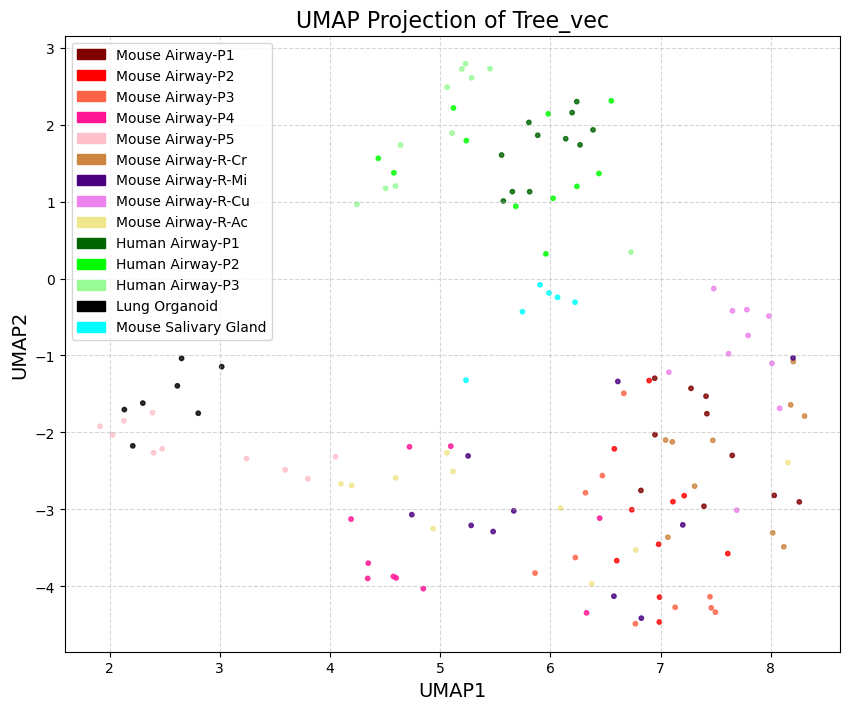

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import umap
from scipy.interpolate import make_interp_spline

np.random.seed(42)
label_names = np.array(['Mouse Airway-P1', 'Mouse Airway-P2', 'Mouse Airway-P3', 'Mouse Airway-P4', 'Mouse Airway-P5', 'Mouse Airway-R-Cr', 'Mouse Airway-R-Mi','Mouse Airway-R-Cu', 'Mouse Airway-R-Ac', 'Human Airway-P1', 'Human Airway-P2', 'Human Airway-P3', 
               'Lung Organoid', 'Mouse Salivary Gland'])
c_list = np.array(['maroon', 'red', 'tomato', 'deeppink', 'pink', 'peru', 'indigo', 'violet', 'khaki', 'darkgreen', 'lime', 'palegreen', 'black', 'cyan', 'blue', 'skyblue'])

tree_vec_all = np.array(tree_vec_all)
tree_vec_marker = np.array(tree_vec_marker)
name_list = np.array(name_list)
name_list2 = np.array(name_list2)

umap_tree = umap.UMAP(metric='canberra', n_neighbors=10, min_dist=0.2, n_components=2, random_state=42)
useful_range = np.concatenate([list(range(0,130)), list(range(137,143))])

tree_vec_2d = umap_tree.fit_transform(tree_vec_all[:, 2:])
                        
fig, ax = tree_viz.plot_umap1("UMAP Projection of Tree_vec", tree_vec_2d, tree_vec_marker, label_names, c_list, figure_name = None)
 
dev_points = np.zeros((5,2))
for i in range(0, 5):
    idx = tree_vec_marker == i
    locs = tree_vec_2d[idx, :]
    dev_points[i, :] = np.mean(locs, axis = 0)

dash_x = dev_points[:,0]
dash_y = dev_points[:,1]
os.makedirs("./figures/", exist_ok=True)
ax.plot(dash_x, dash_y, linestyle='--', color='gray', label='Putative development trace')
# fig.savefig("./figures/D5UMAP-test.pdf")

In [8]:
tree_viz.scatter_with_label(tree_vec_2d, tree_vec_marker, label_names, name_list2, c_list)